In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl

import src as scit
import matplotlib.pyplot as plt
import cv2

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
res=pl.read_csv('private/newest/goterm/meth_increasing.csv')
res

NS,GO,name,depth,enriched,pop_count,study_count,p_corrected,p_uncorrected
str,str,str,i64,bool,i64,i64,f64,f64
"""BP""","""GO:0000122""","""negative regulation of transcr…",11,true,147,62,0.000091,5.1034e-8
"""BP""","""GO:0006355""","""regulation of DNA-templated tr…",9,true,598,187,0.000091,6.2983e-8
"""BP""","""GO:2001141""","""regulation of RNA biosynthetic…",8,true,598,187,0.000091,6.2983e-8
"""BP""","""GO:0006357""","""regulation of transcription by…",10,true,507,162,0.000155,1.3336e-7
"""BP""","""GO:0045892""","""negative regulation of DNA-tem…",10,true,198,72,0.002002,0.000005
…,…,…,…,…,…,…,…,…
"""MF""","""GO:0032559""","""adenyl ribonucleotide binding""",7,false,268,37,0.040648,0.000516
"""MF""","""GO:0005085""","""guanyl-nucleotide exchange fac…",5,false,42,1,0.041294,0.000563
"""MF""","""GO:0005524""","""ATP binding""",8,false,266,37,0.04627,0.000652


In [3]:
# res.filter(pl.col('NS')=='BP').filter(pl.col('enriched')).sort('p_corrected')

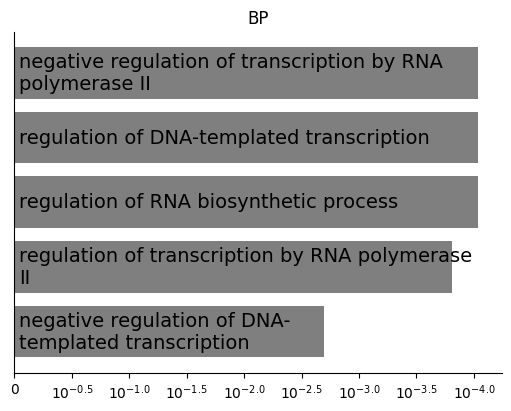

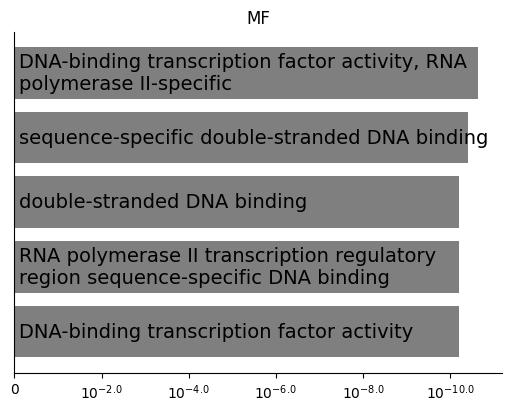

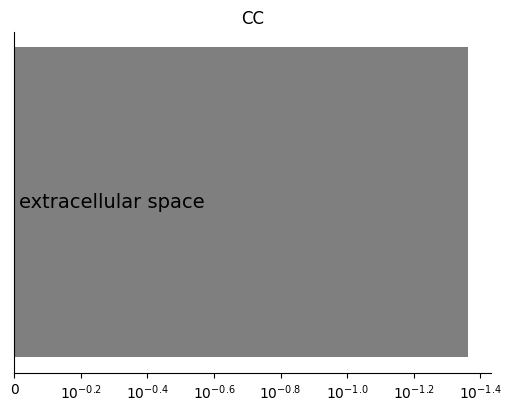

In [4]:
scit.set_defaults(figsize=(5,4))
scit.pl.goea(res, color='tab:gray', mode='enriched_only', n_top=5, plot_type='smart', text_size=14, wrap_width=50)

In [13]:
res=pl.read_csv('private/newest/goterm/upreg_genes_anatomicGO.csv')
cs=list(res['Group'].unique())
cs

['Sense',
 'Tracheal',
 'Muscle somatic',
 'Midgut',
 'Fat Body',
 'Epidermis 1',
 'Epidermis 2',
 'Muscle visceral',
 'Yolk']

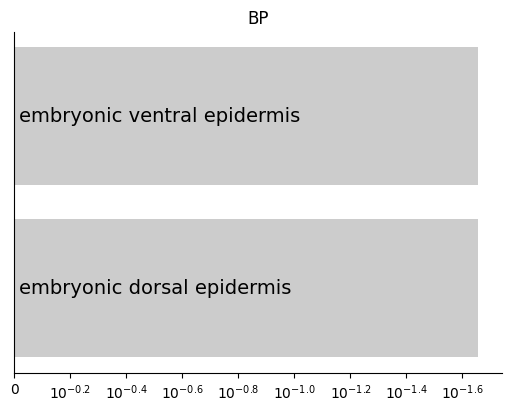

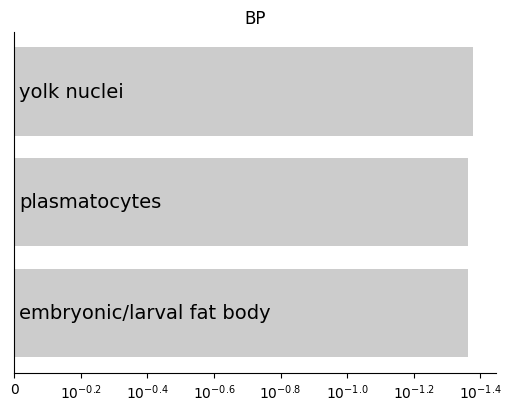

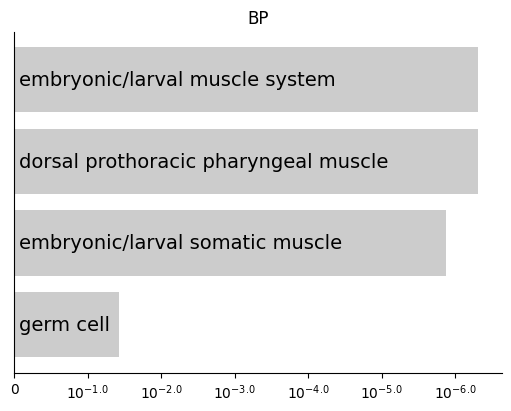

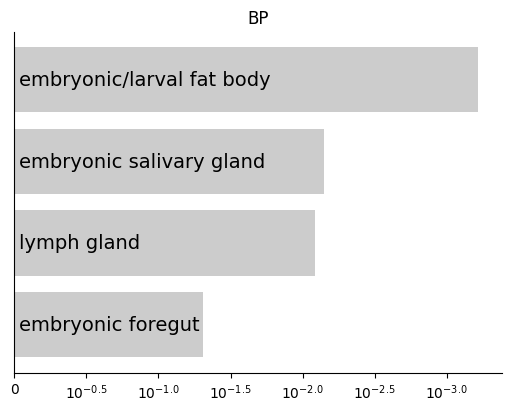

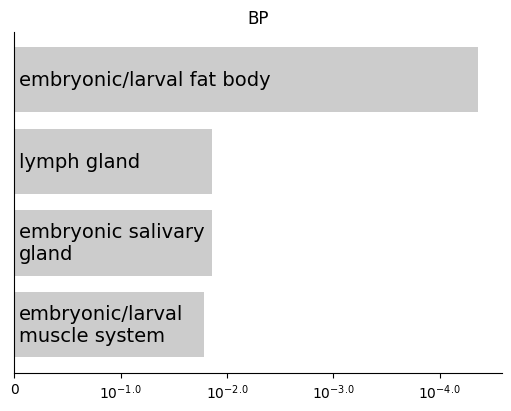

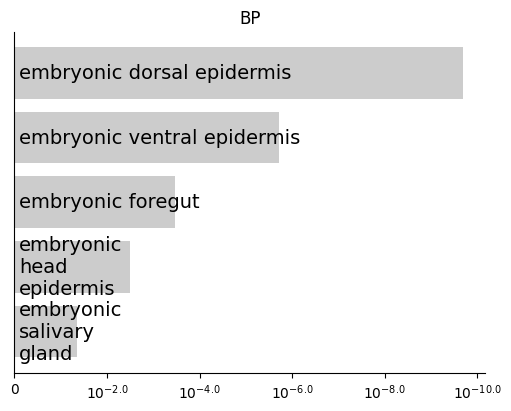

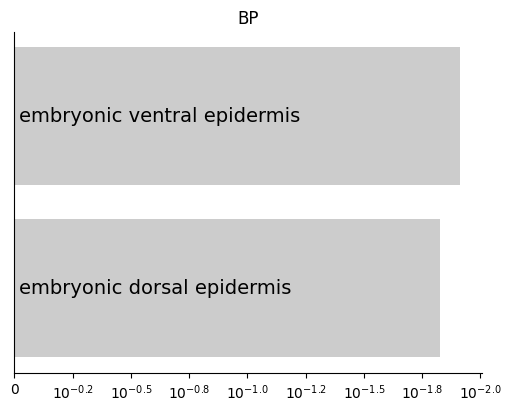

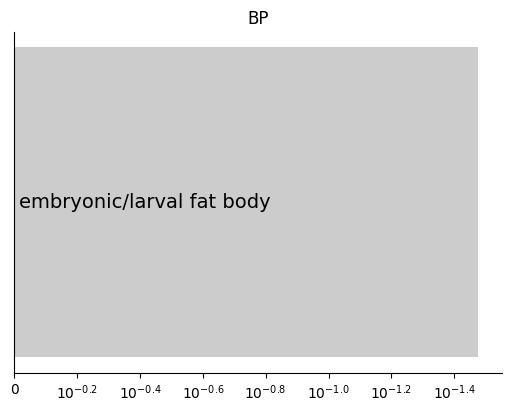

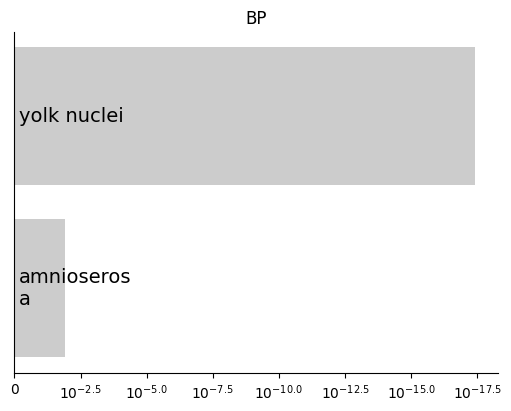

In [14]:
for c in cs:
    df = res.filter(pl.col('Group') ==c).with_columns(
        pl.col('Description').alias('name'),
        pl.col('p.adjust').alias('p_corrected'),
        pl.col('FoldEnrichment').gt(0).alias('enriched'),
        pl.lit('BP').alias('NS')
    )
    scit.set_defaults(figsize=(5,4))
    fs=scit.pl.goea(df, color='#ccc', mode='enriched_only', 
                n_top=5, plot_type='smart', text_size=14, wrap_width=50,show=False)
    fs[0].savefig(f'private/newest/goterm/upreg_genes_{c}.pdf')

In [7]:
res=pl.read_csv('private/newest/goterm/meth_genes_upreg_Muscle_GO_BP.csv')
res = res.with_columns(
    pl.col('Description').alias('name'),
    pl.col('p.adjust').alias('p_corrected'),
    pl.col('FoldEnrichment').gt(0).alias('enriched'),
    pl.lit('BP').alias('NS')
)

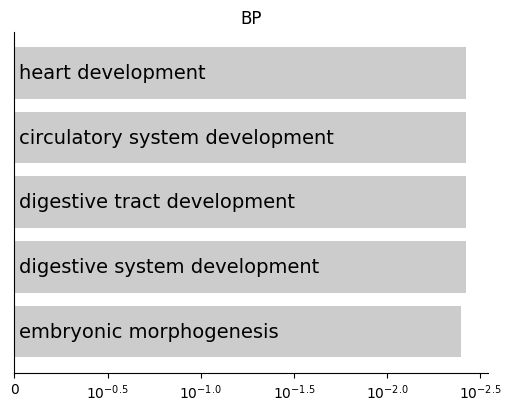

In [8]:
scit.set_defaults(figsize=(5,4))
fs=scit.pl.goea(res, color='#ccc', mode='enriched_only', 
             n_top=5, plot_type='smart', text_size=14, wrap_width=50,show=False)
fs[0].savefig('private/newest/goterm/upreg_genes_muscle_meth.pdf')